In [1]:
import torch
import matplotlib.pyplot as plt
import scienceplots
scienceplots.plt.style.use("science")

In [ ]:
def soft_threshold(x: torch.Tensor, thresh: float) -> torch.Tensor:
    return torch.sign(x) * torch.clamp(torch.abs(x) - thresh, min=0.0)


def estimate_lipschitz_constant(X: torch.Tensor, n_iter: int = 10) -> float:
    """Estimate the Lipschitz constant of the gradient of the smooth part of the objective function using the power iteration method."""
    _, d = X.shape

    v = torch.randn(d, dtype=X.dtype, device=X.device)
    v = v / torch.norm(v)

    for _ in range(n_iter):
        Xv = X @ v
        XtXv = X.T @ Xv

        norm_XtXv = torch.norm(XtXv)
        if norm_XtXv.item() == 0.0:
            return 0.0

        v = XtXv / norm_XtXv

    Xv = X @ v
    L = torch.dot(Xv, Xv) / X.shape[0]
    return L.item()


def fista_lasso(
    X: torch.Tensor,
    y: torch.Tensor,
    lam: float,
    w_init: torch.Tensor | None = None,
    max_iter: int = 100,
    n_iter_lipschitz: int = 10,
    lipschitz_safety_factor: float = 1.1,
    tol: float = 1e-6,
    device: str = "cpu",
    verbose: bool = False,
    lr: float | None = None,
    return_history: bool = False,
) -> dict:
    X = torch.as_tensor(X, dtype=torch.float32, device=device)
    y = torch.as_tensor(y, dtype=torch.float32, device=device)

    if y.ndim == 2 and y.shape[1] == 1:
        y = y[:, 0]

    n, d = X.shape

    if w_init is None:
        w = torch.zeros(d, dtype=torch.float32, device=device)
    else:
        w = torch.as_tensor(w_init, dtype=torch.float32, device=device)
    z = w.clone()
    t = torch.tensor(1.0, dtype=torch.float32, device=device)

    # Lipschitz constant L = ||X||_2^2 / n
    if lr is None:
        if verbose:
            print("Estimating Lipschitz constant...")
        L = estimate_lipschitz_constant(X, n_iter=n_iter_lipschitz)
        L = L * lipschitz_safety_factor
        lr = 1.0 / L
        if verbose:
            print(f"Estimated Lipschitz constant: {L:.4f}, Learning rate: {lr:.4f}")

    results: dict = {}

    results["lr"] = lr
    history = []

    for k in range(max_iter):
        grad = X.T @ (X @ z - y) / n
        w_new = soft_threshold(z - lr * grad, lr * lam)

        t_new = (1.0 + torch.sqrt(1.0 + 4.0 * t * t)) / 2.0
        z = w_new + ((t - 1.0) / t_new) * (w_new - w)
        t = t_new

        diff = torch.norm(w_new - w)
        w = w_new

        if return_history or (verbose and k % 10 == 0):
            residual = X @ w - y
            loss_smooth = 0.5 * torch.sum(residual * residual) / n
            loss_l1 = lam * torch.sum(torch.abs(w))
            obj = loss_smooth + loss_l1

        if return_history:
            history.append(obj.item())

        if verbose and (k+1) % 10 == 0:
            print(
                f"Iter {k+1}: Objective={obj.item():.4f}, Loss={loss_smooth.item():.4f}, L1={loss_l1.item():.4f}, Diff={diff.item():.4e}"
            )

        if diff.item() < tol:
            break

    results["w"] = w
    if return_history:
        results["history"] = history
    return results

In [3]:
torch.manual_seed(0)

n = 90_000
d = n // 4
k = n // 6

X = torch.bernoulli(0.5 * torch.ones(n, d)) * 2 - 1
w_true = torch.zeros(d)
w_true[:k] = torch.randn(k)
y = X @ w_true + 0.1 * torch.randn(n)

lam = 0.01

In [4]:
# By default, the learning rate is calculated based on the Lipschitz constant.
results = fista_lasso(
    X,
    y,
    lam,
    # w_init = w_true + 0.1 * torch.randn(d),  # ランダムな初期値
    max_iter=20,
    tol=1e-7,
    verbose=True,
    return_history=True,
    n_iter_lipschitz=5,
)

Estimating Lipschitz constant...
Estimated Lipschitz constant: 2.1641, Learning rate: 0.4621
Iter 10: Objective=118.9244, Loss=0.9154, L1=118.0090, Diff=1.0491e+00
Iter 20: Objective=117.5768, Loss=0.9489, L1=116.6279, Diff=1.2225e-01


In [5]:
# Setting the learning rate manually to 0.1.
results2 = fista_lasso(
    X,
    y,
    lam,
    # w_init = w_true + 0.1 * torch.randn(d),  # ランダムな初期値
    max_iter=20,
    tol=1e-7,
    verbose=True,
    lr=0.1,
    return_history=True,
)

Iter 10: Objective=272.0009, Loss=160.8817, L1=111.1192, Diff=7.0108e+00
Iter 20: Objective=125.8978, Loss=5.2884, L1=120.6095, Diff=1.4570e+00


In [6]:
w_hat = results["w"]

print(f"=== Lipschitz-based learning rate ({results['lr']})===")
print("estimated w:")
print(w_hat)

print("mse:", torch.mean((w_hat - w_true) ** 2).item())
print(
    "cosine similarity:",
    torch.nn.functional.cosine_similarity(w_hat, w_true, dim=0).item(),
)
print("non-zero count:", torch.sum(w_hat != 0).item())
print("true non-zero count:", torch.sum(w_true != 0).item())

w_hat = results2["w"]

print("=== Manual learning rate (0.1) ===")
print("estimated w:")
print(w_hat)

print("mse:", torch.mean((w_hat - w_true) ** 2).item())
print(
    "cosine similarity:",
    torch.nn.functional.cosine_similarity(w_hat, w_true, dim=0).item(),
)
print("non-zero count:", torch.sum(w_hat != 0).item())
print("true non-zero count:", torch.sum(w_true != 0).item())

=== Lipschitz-based learning rate (0.4620822072029114)===
estimated w:
tensor([-1.3302,  0.2055, -1.6349,  ..., -0.0000,  0.0000,  0.0000])
mse: 0.00012769036402460188
cosine similarity: 0.9999517202377319
non-zero count: 15132
true non-zero count: 15000
=== Manual learning rate (0.1) ===
estimated w:
tensor([-1.3458,  0.1936, -1.6466,  ..., -0.0088, -0.0199,  0.0058])
mse: 0.0007595901261083782
cosine similarity: 0.9995154738426208
non-zero count: 22050
true non-zero count: 15000


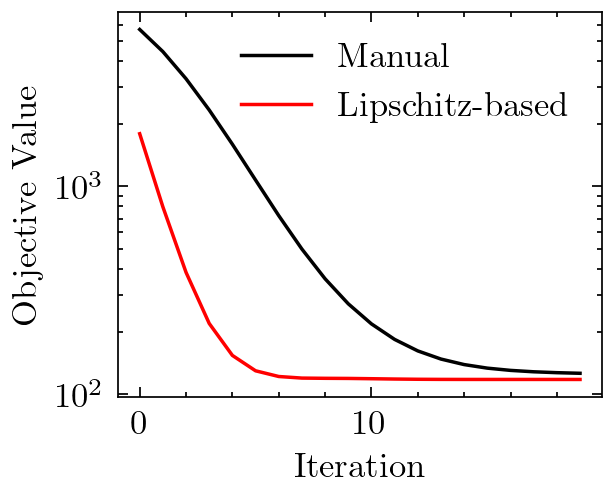

In [7]:
history = results["history"]
history2 = results2["history"]

fig = plt.figure(figsize=(2.5,2), dpi=250)
ax = fig.add_subplot()
ax.plot(history2, label="Manual", color="k")
ax.plot(history, label="Lipschitz-based", color="r")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Value")
ax.set_yscale("log")
ax.legend()
plt.show()